# USDZAR 1-month-ahead forecasting — results overview

Loads the **cached** weekly dataset and backtest results (run `make all`
first if `data/results/` is empty) and renders every table and figure
inline. All figure code lives in `src/plots.py` — this notebook only calls
it, so the saved report figures and this notebook can never drift apart.

In [1]:
# Make the repo root importable when the notebook runs from notebooks/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from src.config import DATA_PROCESSED
from src.evaluate import load_results, overall_table, per_year_table, dm_table
from src import plots

weekly = pd.read_parquet(DATA_PROCESSED / 'weekly.parquet')
weekly.tail()

,usdzar,gold,sa_3m,sa_10y,dxy,vix,us_3m,brent,baa,us_10y,platinum,log_usdzar,d4_log_gold,d4_log_platinum,d4_log_brent,d4_log_dxy,d4_vix,d4_credit,rate_spread,mr_gap
friday,,,,,,,,,,,,,,,,,,,,
2026-06-12,16.2682,4204.500,6.99,8.77,119.5073,17.68,3.78,88.64,6.01,4.48,1716.0,2.789212,-0.076920,-0.142596,-0.251264,0.001883,-0.75,-0.09,3.21,-0.042371
2026-06-19,16.4775,4157.725,6.99,8.58,120.3958,16.78,3.83,80.46,5.97,4.46,1664.0,2.801996,-0.081468,-0.143101,-0.284134,0.009254,0.08,-0.06,3.16,-0.027858
2026-06-26,16.4550,4060.000,6.99,8.49,120.8866,18.41,3.83,70.16,5.94,4.38,1615.0,2.800629,-0.110830,-0.170905,-0.280530,0.016753,3.09,-0.01,3.16,-0.027646
2026-07-03,16.2146,4167.700,7.00,8.50,120.6902,15.81,3.82,68.68,6.03,4.49,1638.0,2.785912,-0.057445,-0.080324,-0.348238,0.005043,-5.70,0.03,3.18,-0.040823
2026-07-10,16.3105,4100.675,7.01,8.57,120.5046,15.03,3.85,74.34,6.14,4.56,1625.0,2.791809,-0.025004,-0.054488,-0.175934,0.008310,-2.65,0.05,3.16,-0.033217


In [2]:
results = load_results()
overall = overall_table(results)
overall

,rmse,mae,hit_rate,n,rmse_vs_ar1
model,,,,,
AR1,0.558862,0.445005,0.563218,261.0,1.000000
RandomWalk,0.559989,0.448005,NaN,261.0,1.002017
Lasso+RW,0.563753,0.465930,0.463602,261.0,1.008752
Lasso,0.567369,0.465900,0.463602,261.0,1.015223
RW+Drift,0.567739,0.466067,0.463602,261.0,1.015884
Ridge,0.589238,0.480432,0.448276,261.0,1.054353
OLS,0.594990,0.485311,0.452107,261.0,1.064646
SVM,0.639034,0.526767,0.478927,261.0,1.143456


In [3]:
per_year_table(results)

model,AR1,Lasso,Lasso+RW,OLS,RW+Drift,RandomWalk,Ridge,SVM
year,,,,,,,,
2021,0.506840,0.516029,0.515663,0.563546,0.516372,0.510154,0.552315,0.534658
2022,0.693671,0.685547,0.680969,0.705490,0.685888,0.692795,0.700365,0.678276
2023,0.654570,0.640258,0.631995,0.672525,0.640916,0.649335,0.667645,0.713058
2024,0.442021,0.461982,0.460575,0.487711,0.462360,0.444853,0.482869,0.636181
2025,0.448094,0.500989,0.498909,0.515084,0.501074,0.457397,0.512191,0.620549


In [4]:
# Diebold-Mariano vs the AR(1) benchmark (negative stat = model better)
dm_table(results)

,dm_stat,p_value,n,better_than_ar1
model,,,,
Lasso+RW,0.351340,0.725618,261,False
RandomWalk,0.375946,0.707264,261,False
Lasso,0.626692,0.531411,261,False
RW+Drift,0.654640,0.513278,261,False
Ridge,2.439544,0.015375,261,False
OLS,2.774652,0.005927,261,False
SVM,2.865425,0.004505,261,False


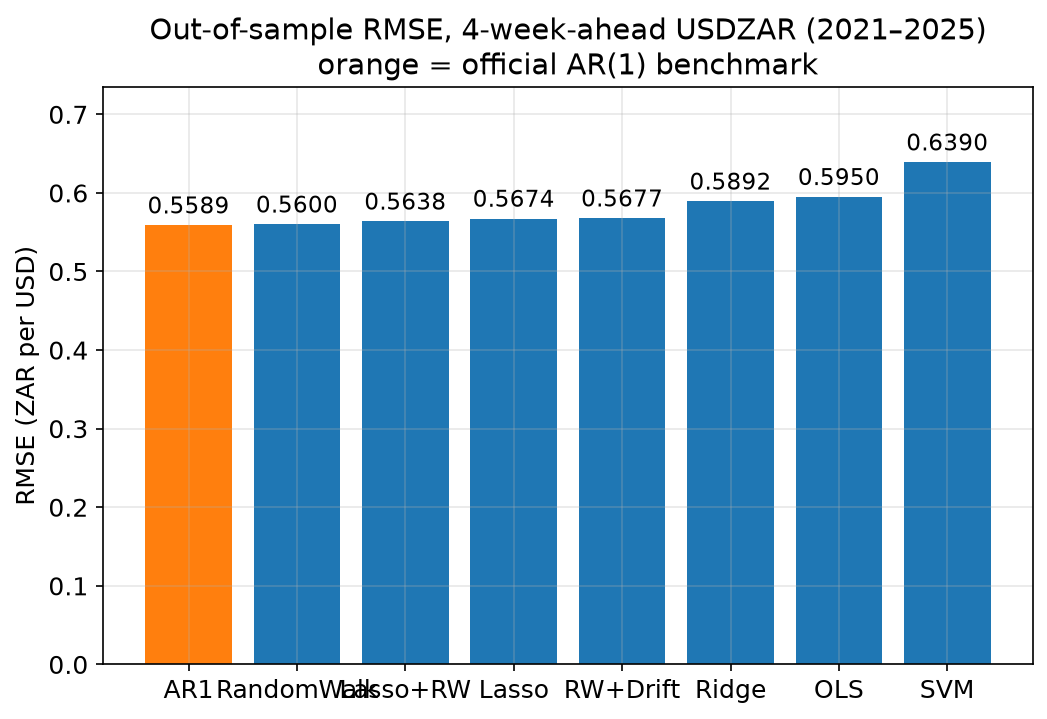

In [5]:
plots.fig_rmse_bar(overall);

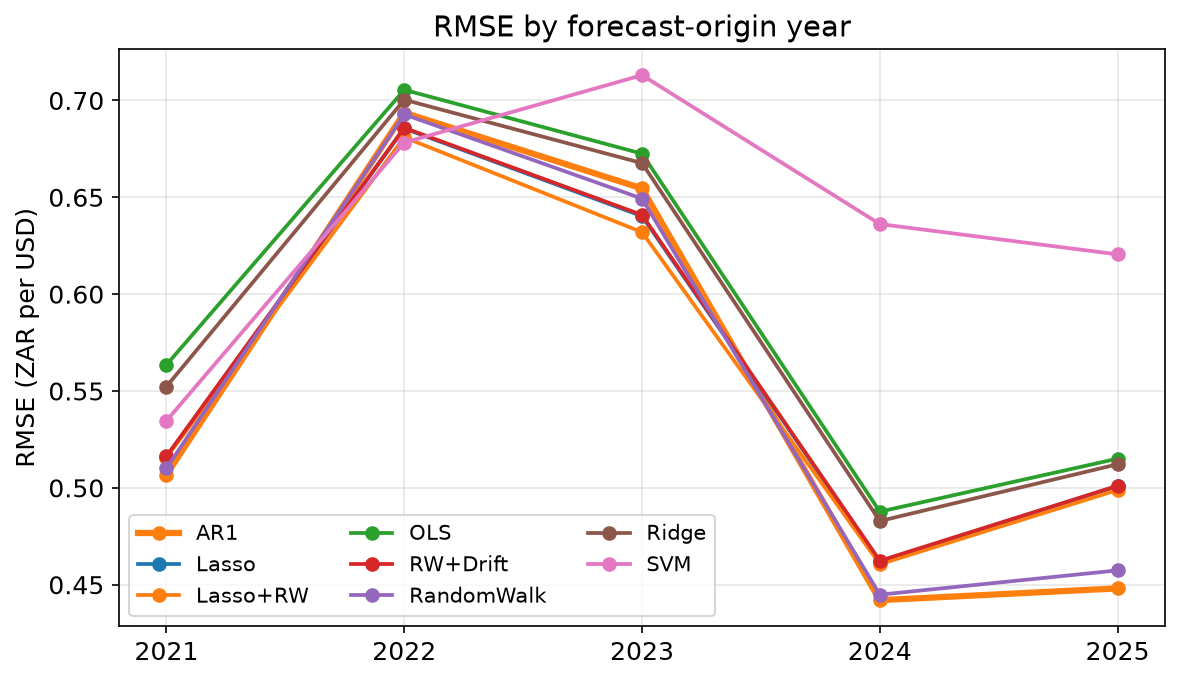

In [6]:
plots.fig_rmse_per_year(per_year_table(results));

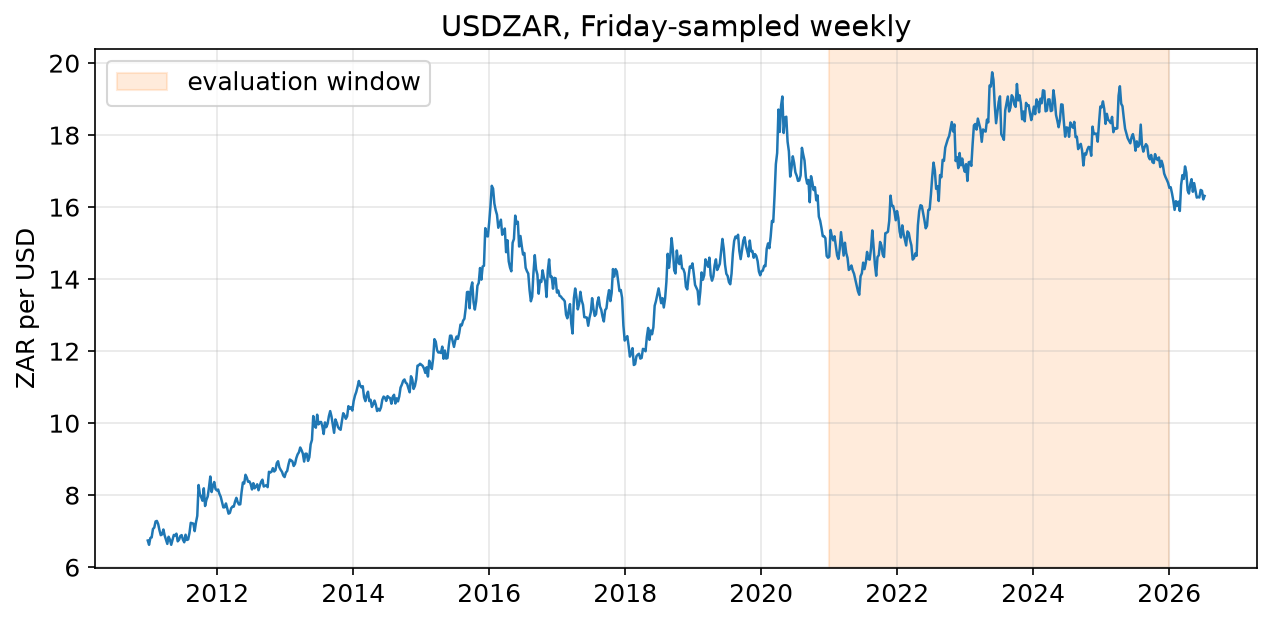

In [7]:
plots.fig_history(weekly);

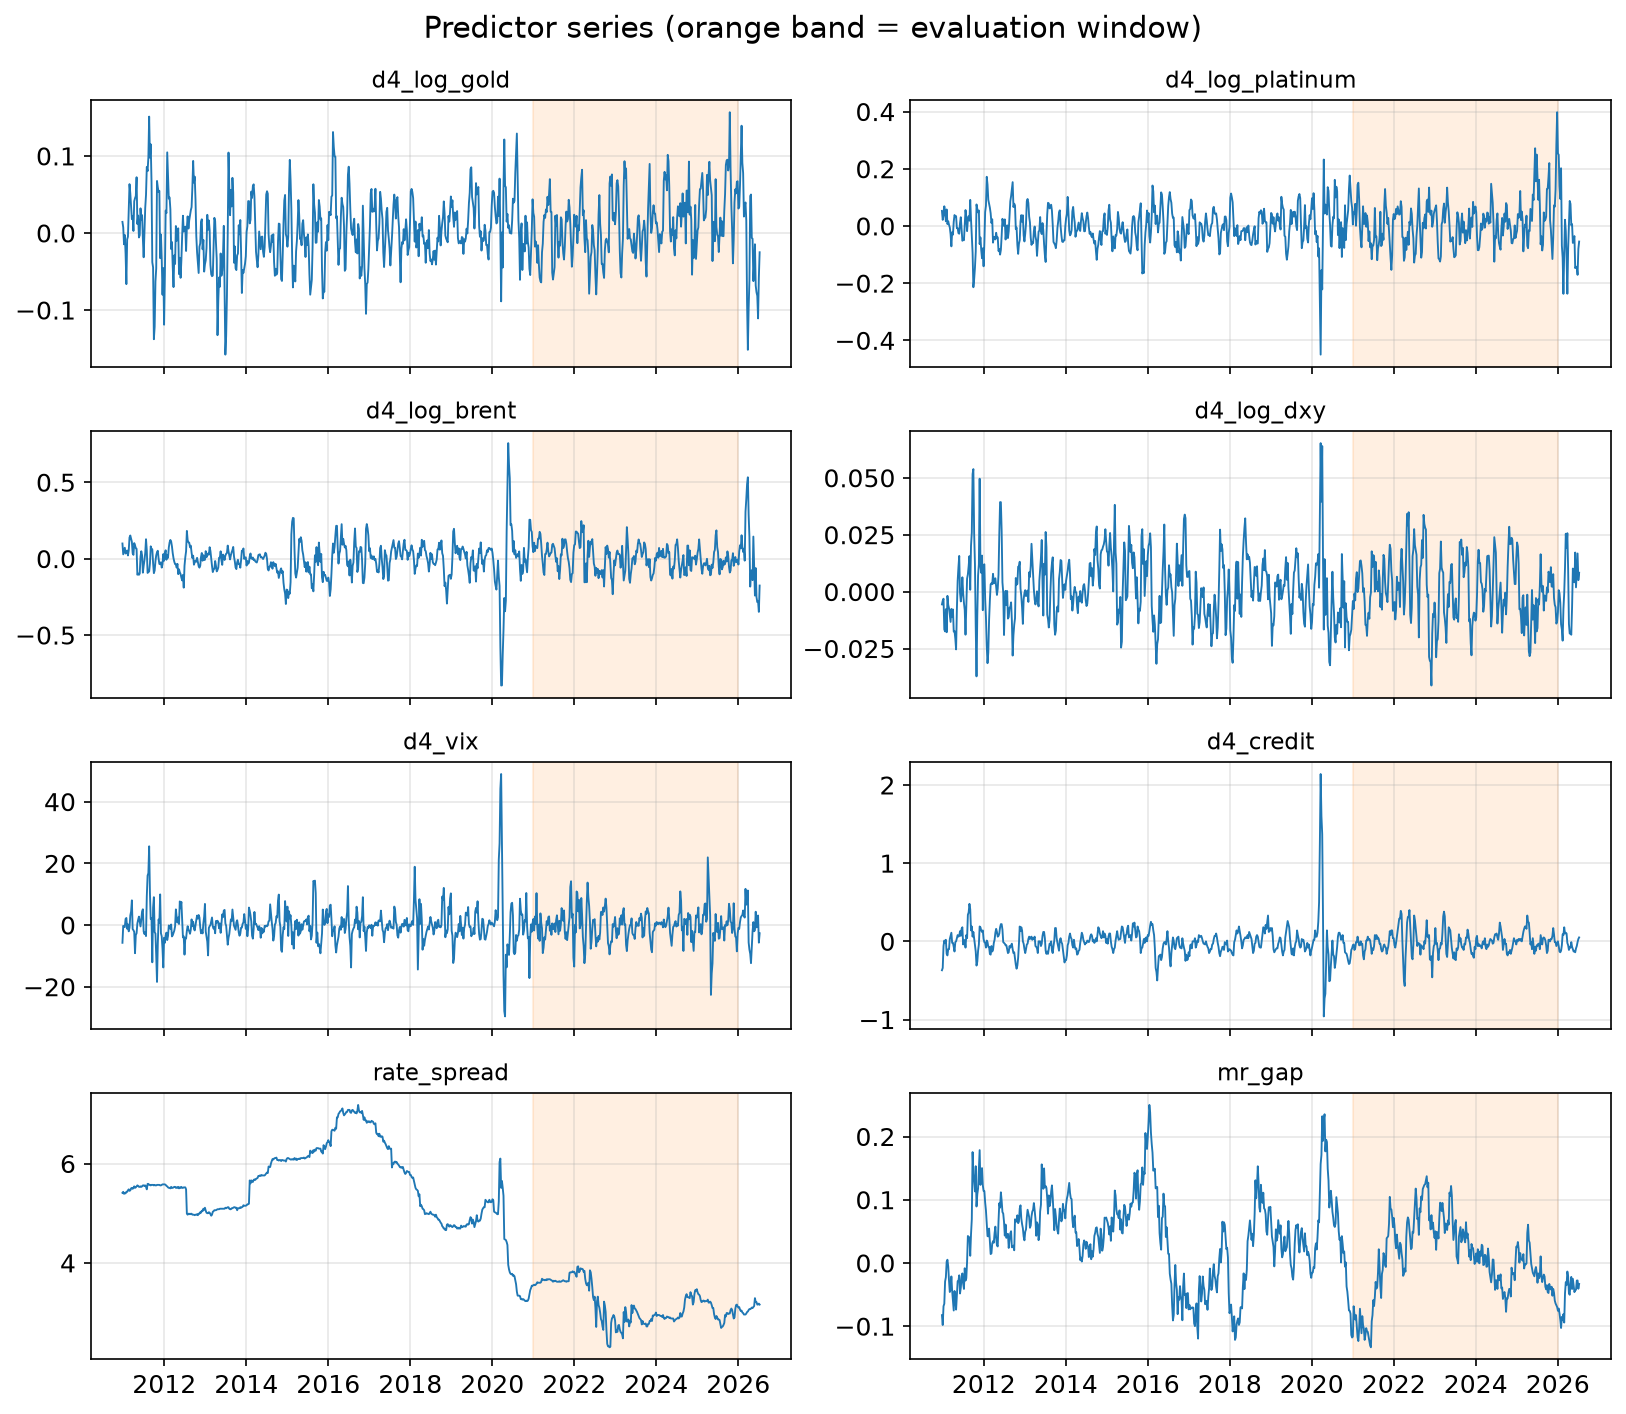

In [8]:
plots.fig_predictors(weekly);

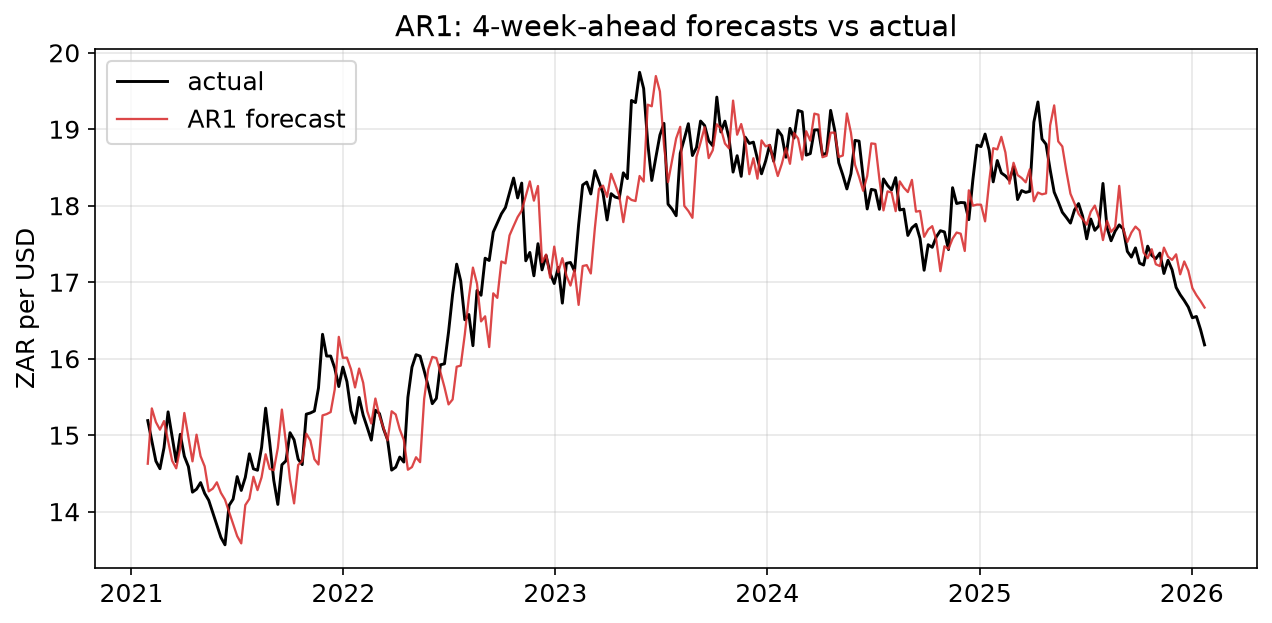

In [9]:
best_model = overall.index[0]
plots.fig_forecast_vs_actual(results, best_model);

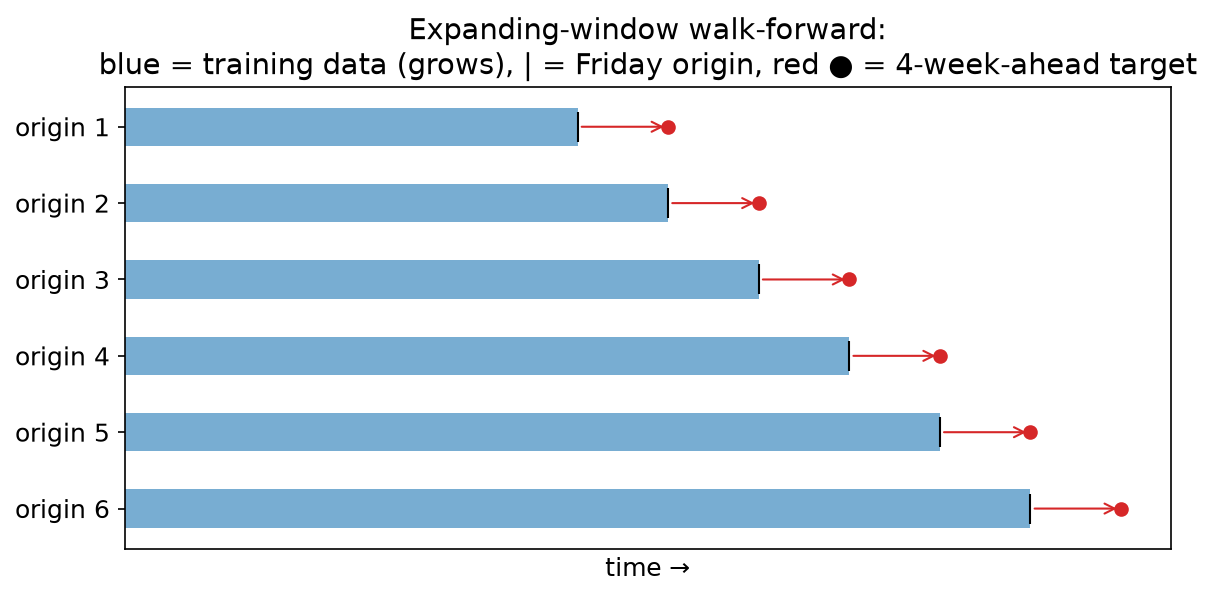

In [10]:
plots.fig_schematic();